In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
import joblib

# -------------------------------------------------------------------------
# [조건 1] 데이터 준비 및 소규모 훈련 샘플링 (컬럼명 자동 매칭 버전)
# -------------------------------------------------------------------------

url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url)


df.columns = df.columns.str.strip()


print("==== 현재 데이터셋의 실제 컬럼명 목록 ====")
print(list(df.columns))
print("=========================================\n")


col_mapping = {col.lower().replace('_', ' '): col for col in df.columns}


desired_features = ['adult mortality', 'bmi', 'gdp', 'alcohol']
desired_target = 'life expectancy'


features = [col_mapping[f] for f in desired_features if f in col_mapping]
target = col_mapping[desired_target]

print(f"🎯 매칭된 실제 독립변수(Features): {features}")
print(f"🎯 매칭된 실제 종속변수(Target): {target}\n")


if len(features) < 3:
    print("⚠️ 지정한 특성을 찾지 못해 데이터셋 내의 다른 컬럼을 대안으로 선택합니다.")

    alternative_features = [col for col in df.columns if col not in ['Schooling', target]][:4]
    features = alternative_features
    print(f"🔄 대체된 독립변수: {features}")


df = df.dropna()


X = df[features]
y = df[target]


X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train_sub = X_train_full.sample(n=50, random_state=42)
y_train_sub = y_train_full.loc[X_train_sub.index]

# -------------------------------------------------------------------------
# [조건 2] 파이프라인 기반 모델 3종 학습 및 저장 (동일)
# -------------------------------------------------------------------------
model1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model2_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', LinearRegression())
])

model3_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', Ridge(alpha=1.0))
])


model1_pipe.fit(X_train_sub, y_train_sub)
model2_pipe.fit(X_train_sub, y_train_sub)
model3_pipe.fit(X_train_sub, y_train_sub)


joblib.dump(model1_pipe, 'model1_linear.pkl')
joblib.dump(model2_pipe, 'model2_poly.pkl')
joblib.dump(model3_pipe, 'model3_ridge.pkl')
joblib.dump((X_train_sub, y_train_sub, X_test, y_test, features), 'data_splits.pkl')

print("🎉 모델 학습 및 저장 완벽 완료!")

==== 현재 데이터셋의 실제 컬럼명 목록 ====
['Country', 'Year', 'Status', 'Life expectancy', 'Adult mortality', 'Infant deaths', 'Alcohol', 'Percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'Thinness 1-19 years', 'Thinness 5-9 years', 'Income composition of resources', 'Schooling']

🎯 매칭된 실제 독립변수(Features): ['Adult mortality', 'BMI', 'GDP', 'Alcohol']
🎯 매칭된 실제 종속변수(Target): Life expectancy

🎉 모델 학습 및 저장 완벽 완료!


In [23]:
# 1. 기존에 켜져 있던 Streamlit과 ngrok 프로세스를 모두 강제 종료 (초기화)
!pkill -f streamlit
!pkill -f ngrok

# 2. 필수 라이브러리 다시 한번 확인 설치
!pip install pyngrok ngrok streamlit -q

print("✅ 초기화 완료! 이제 아래 셀에서 app.py를 생성하고 배포합니다.")

✅ 초기화 완료! 이제 아래 셀에서 app.py를 생성하고 배포합니다.


In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import r2_score, mean_squared_error


st.set_page_config(layout="wide", page_title="기대수명 예측 대시보드")
st.title("🧬 WHO 기대수명 예측 및 모델 성능 비교 웹 서비스")

# -------------------------------------------------------------------------
# 🔥 [오류 수정] @st.set_data를 올바른 캐싱 데코레이터인 @st.cache_resource로 변경
# -------------------------------------------------------------------------
@st.cache_resource
def load_resources():
    m1 = joblib.load('model1_linear.pkl')
    m2 = joblib.load('model2_poly.pkl')
    m3 = joblib.load('model3_ridge.pkl')
    X_train, y_train, X_test, y_test, features = joblib.load('data_splits.pkl')
    return m1, m2, m3, X_train, y_train, X_test, y_test, features

try:
    model1, model2, model3, X_train, y_train, X_test, y_test, features = load_resources()
except FileNotFoundError:
    st.error("모델 파일(.pkl)을 찾을 수 없습니다. 먼저 학습 스크립트를 실행하여 모델을 생성해주세요.")
    st.stop()

# -------------------------------------------------------------------------
# [조건 3] 웹 서비스 내 '각 모델의 성능 비교' 화면 구현 (2단계)
# -------------------------------------------------------------------------
st.header("📊 [2단계] 각 모델의 성능 비교")


def calculate_metrics(model, X_tr, y_tr, X_te, y_te):
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    r2_train = r2_score(y_tr, pred_train)
    r2_test = r2_score(y_te, pred_test)
    mse_train = mean_squared_error(y_tr, pred_train)
    mse_test = mean_squared_error(y_te, pred_test)


    if 'poly' in model.named_steps:
        complexity = model.named_steps['poly'].n_output_features_
    else:
        complexity = X_tr.shape[1]

    return r2_train, r2_test, mse_train, mse_test, complexity

m1_metrics = calculate_metrics(model1, X_train, y_train, X_test, y_test)
m2_metrics = calculate_metrics(model2, X_train, y_train, X_test, y_test)
m3_metrics = calculate_metrics(model3, X_train, y_train, X_test, y_test)


metrics_data = {
    'Model': ['Model 1 (Linear)', 'Model 2 (Poly)', 'Model 3 (Ridge)'],
    'Train R^2': [m1_metrics[0], m2_metrics[0], m3_metrics[0]],
    'Test R^2': [m1_metrics[1], m2_metrics[1], m3_metrics[1]],
    'Train MSE': [m1_metrics[2], m2_metrics[2], m3_metrics[2]],
    'Test MSE': [m1_metrics[3], m2_metrics[3], m3_metrics[3]],
    'Complexity': [m1_metrics[4], m2_metrics[4], m3_metrics[4]]
}
metrics_df = pd.DataFrame(metrics_data).set_index('Model')


st.subheader("📋 성능 평가 지표 테이블")
st.dataframe(metrics_df, use_container_width=True)


st.subheader("📉 Test R^2 점수 비교 시각화")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=metrics_data['Model'], y=metrics_data['Test R^2'], ax=ax, palette='Set2')
ax.set_title("Comparison of Test R^2 Scores")
ax.set_ylabel("Test R^2 Score")
ax.set_ylim(min(metrics_data['Test R^2']) - 0.1, max(metrics_data['Test R^2']) + 0.1)


for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

st.pyplot(fig)

st.markdown("---")

# -------------------------------------------------------------------------
# [조건 4] 웹 서비스 구현 및 실시간 예측 UI 구성 (3단계)
# -------------------------------------------------------------------------
st.header("🔮 [3단계] 실시간 기대수명 예측 UI")


st.sidebar.header("🛠️ 특성 제어 슬라이더")


input_values = {}
for col in features:
    min_val = float(X_train[col].min())
    max_val = float(X_train[col].max())
    mean_val = float(X_train[col].mean())

    input_values[col] = st.sidebar.slider(
        label=f"{col} 범위",
        min_value=min_val * 0.5,
        max_value=max_val * 1.5,
        value=mean_val
    )


st.sidebar.markdown("---")
selected_model_name = st.sidebar.selectbox(
    "🤖 분석할 모델을 선택하세요",
    ['Linear', 'Poly', 'Ridge']
)


model_map = {
    'Linear': model1,
    'Poly': model2,
    'Ridge': model3
}
chosen_model = model_map[selected_model_name]


input_df = pd.DataFrame([input_values])
prediction = chosen_model.predict(input_df)[0]


st.subheader(f"🎯 {selected_model_name} 모델의 실시간 예측 결과")
st.markdown(f"<h1 style='text-align: center; color: #1E88E5; font-size: 50px;'>예측된 기대수명: {prediction:.2f} 세</h1>", unsafe_allow_html=True)


st.caption("현재 선택된 슬라이더 입력값:")
st.dataframe(input_df)

Overwriting app.py


In [26]:
!pkill -f streamlit
!pkill -f ngrok

import time
time.sleep(1)


!nohup streamlit run app.py --server.port 8051 > streamlit.log 2>&1 &


import ngrok
from pyngrok import ngrok

AUTH_TOKEN = "3DyfLv2iJnYVnBC5HKDkFNo9e0z_6ci7t6DKXmxn1Fdw1eaei"
ngrok.set_auth_token(AUTH_TOKEN)

public_url = ngrok.connect(8051, bind_tls=True)
print("\n🎉 문법 오류 수정 및 배포 성공!")
print("👉 새로운 접속 주소:", public_url)


🎉 문법 오류 수정 및 배포 성공!
👉 새로운 접속 주소: NgrokTunnel: "https://rocket-lavender-oppressed.ngrok-free.dev" -> "http://localhost:8051"


In [17]:
!curl http://localhost:8051

curl: (7) Failed to connect to localhost port 8051 after 0 ms: Connection refused


In [18]:
!streamlit run app.py --server.port 8051

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


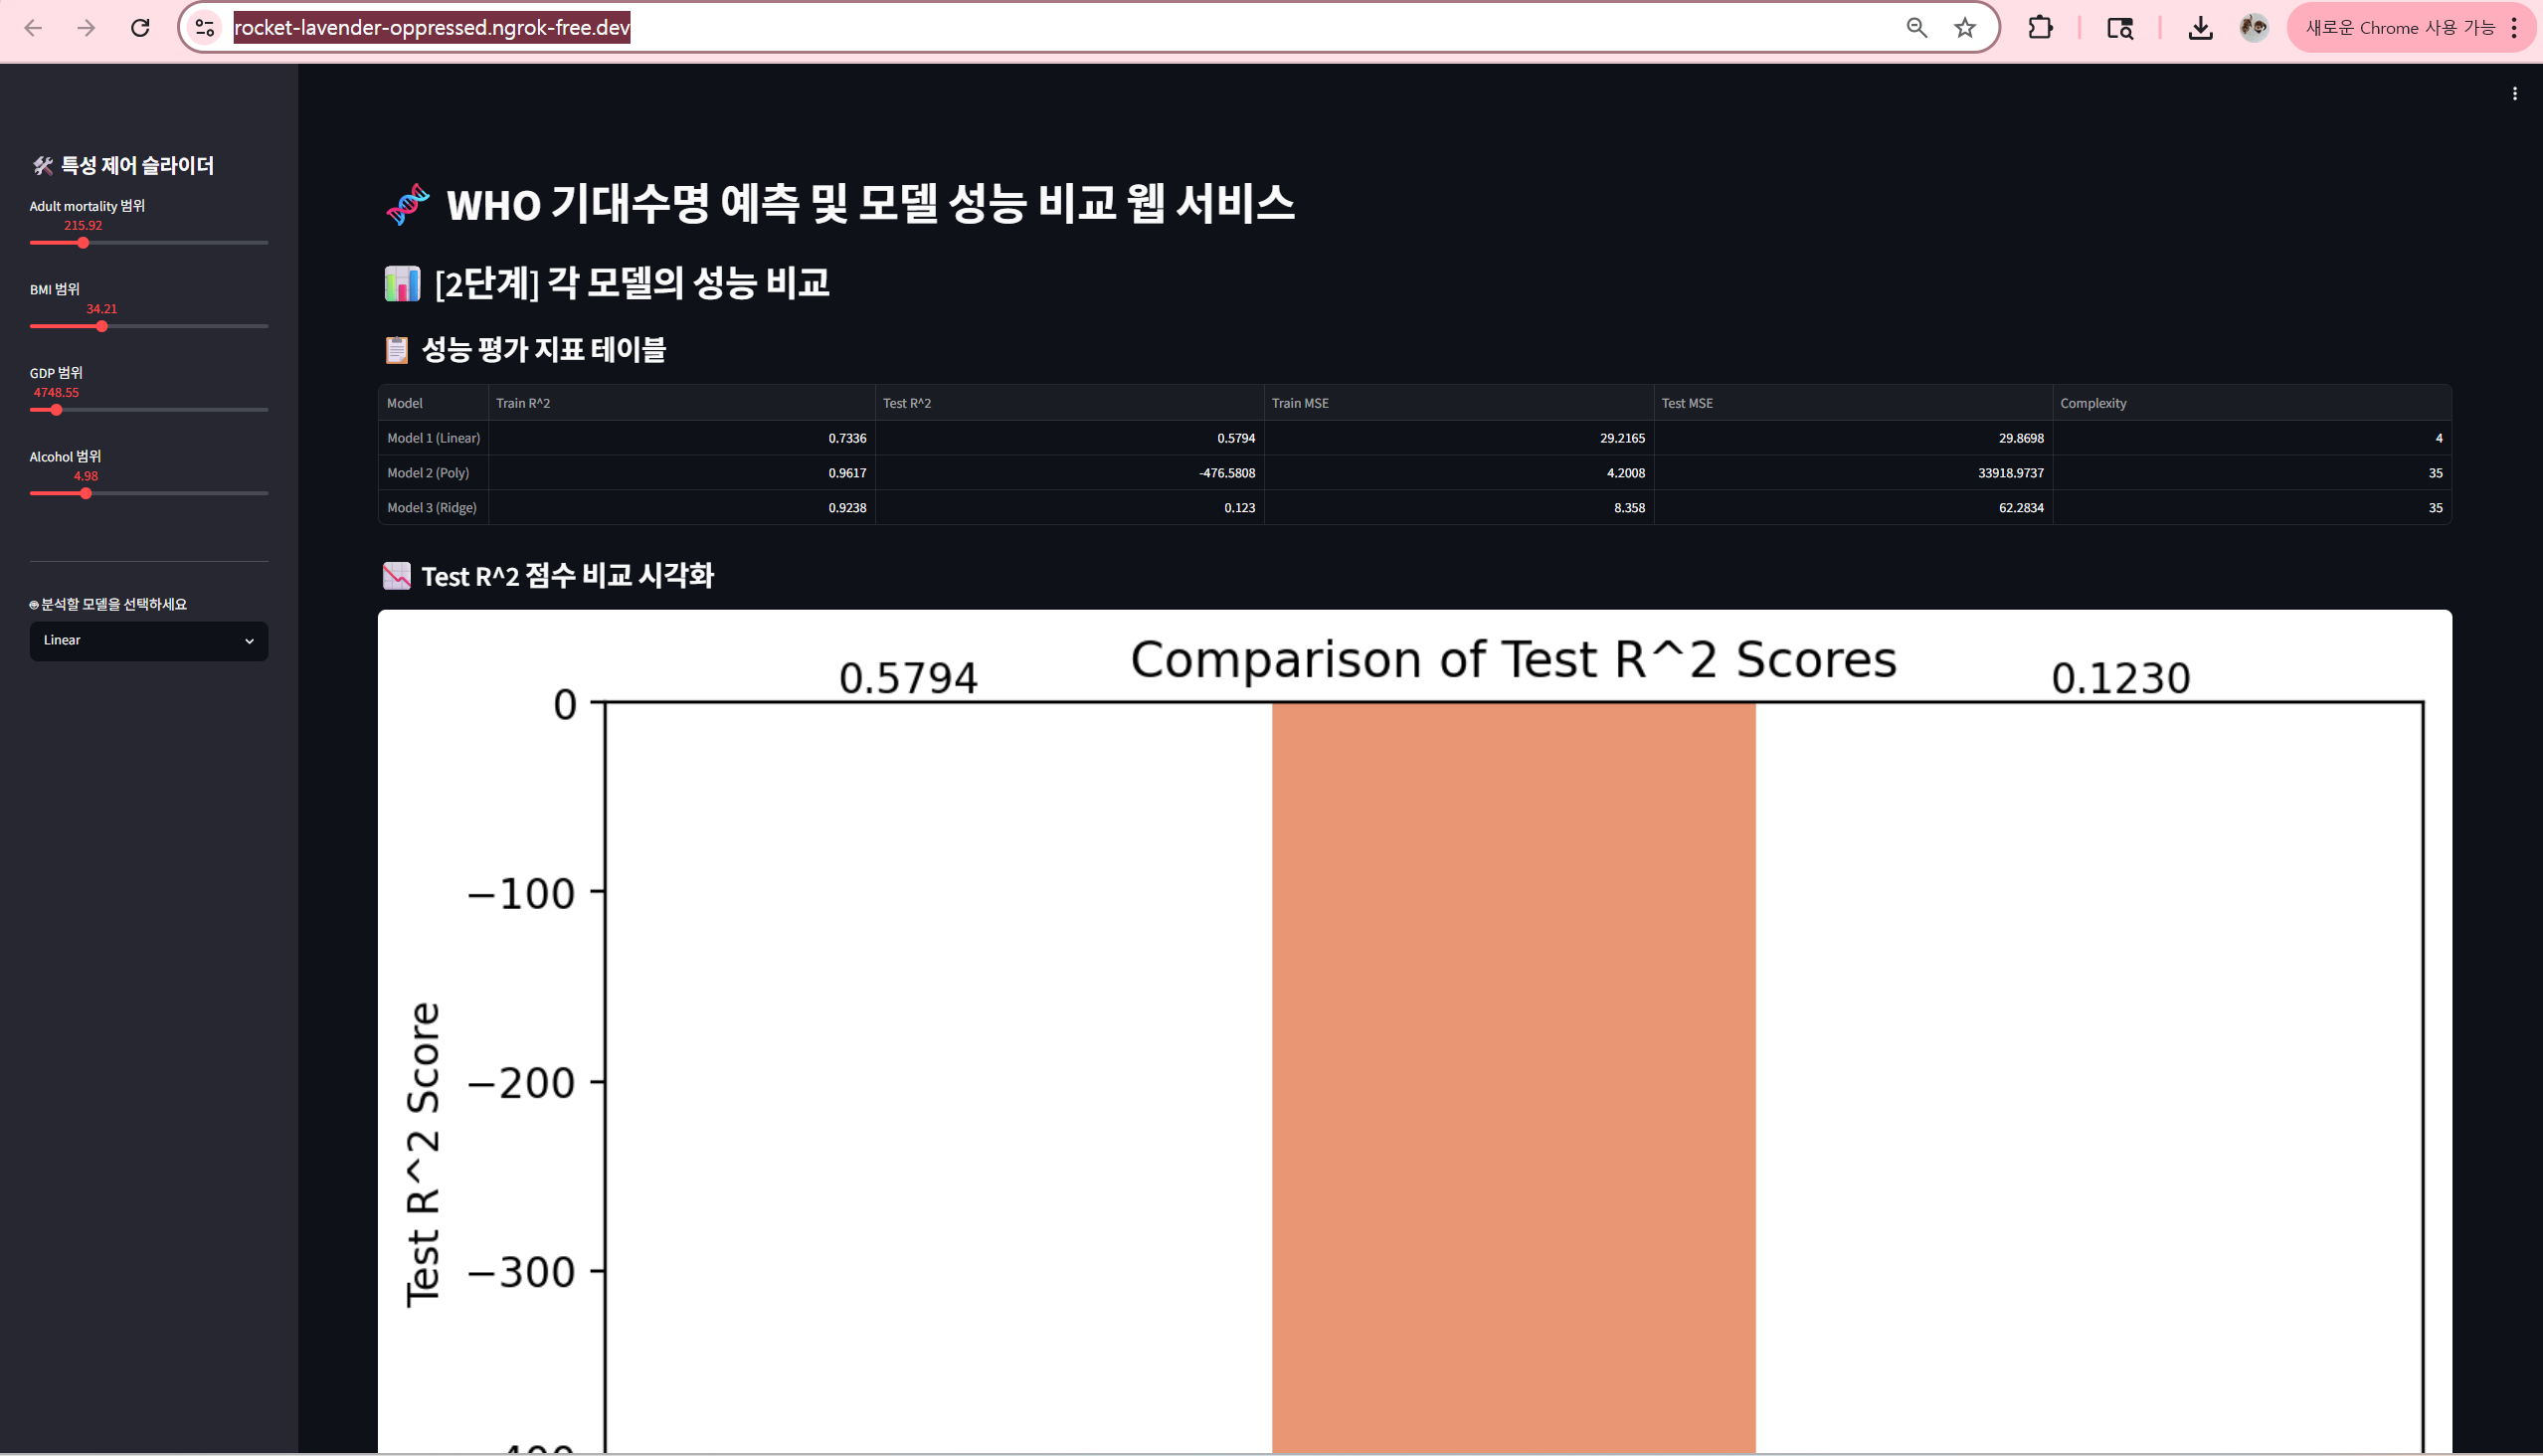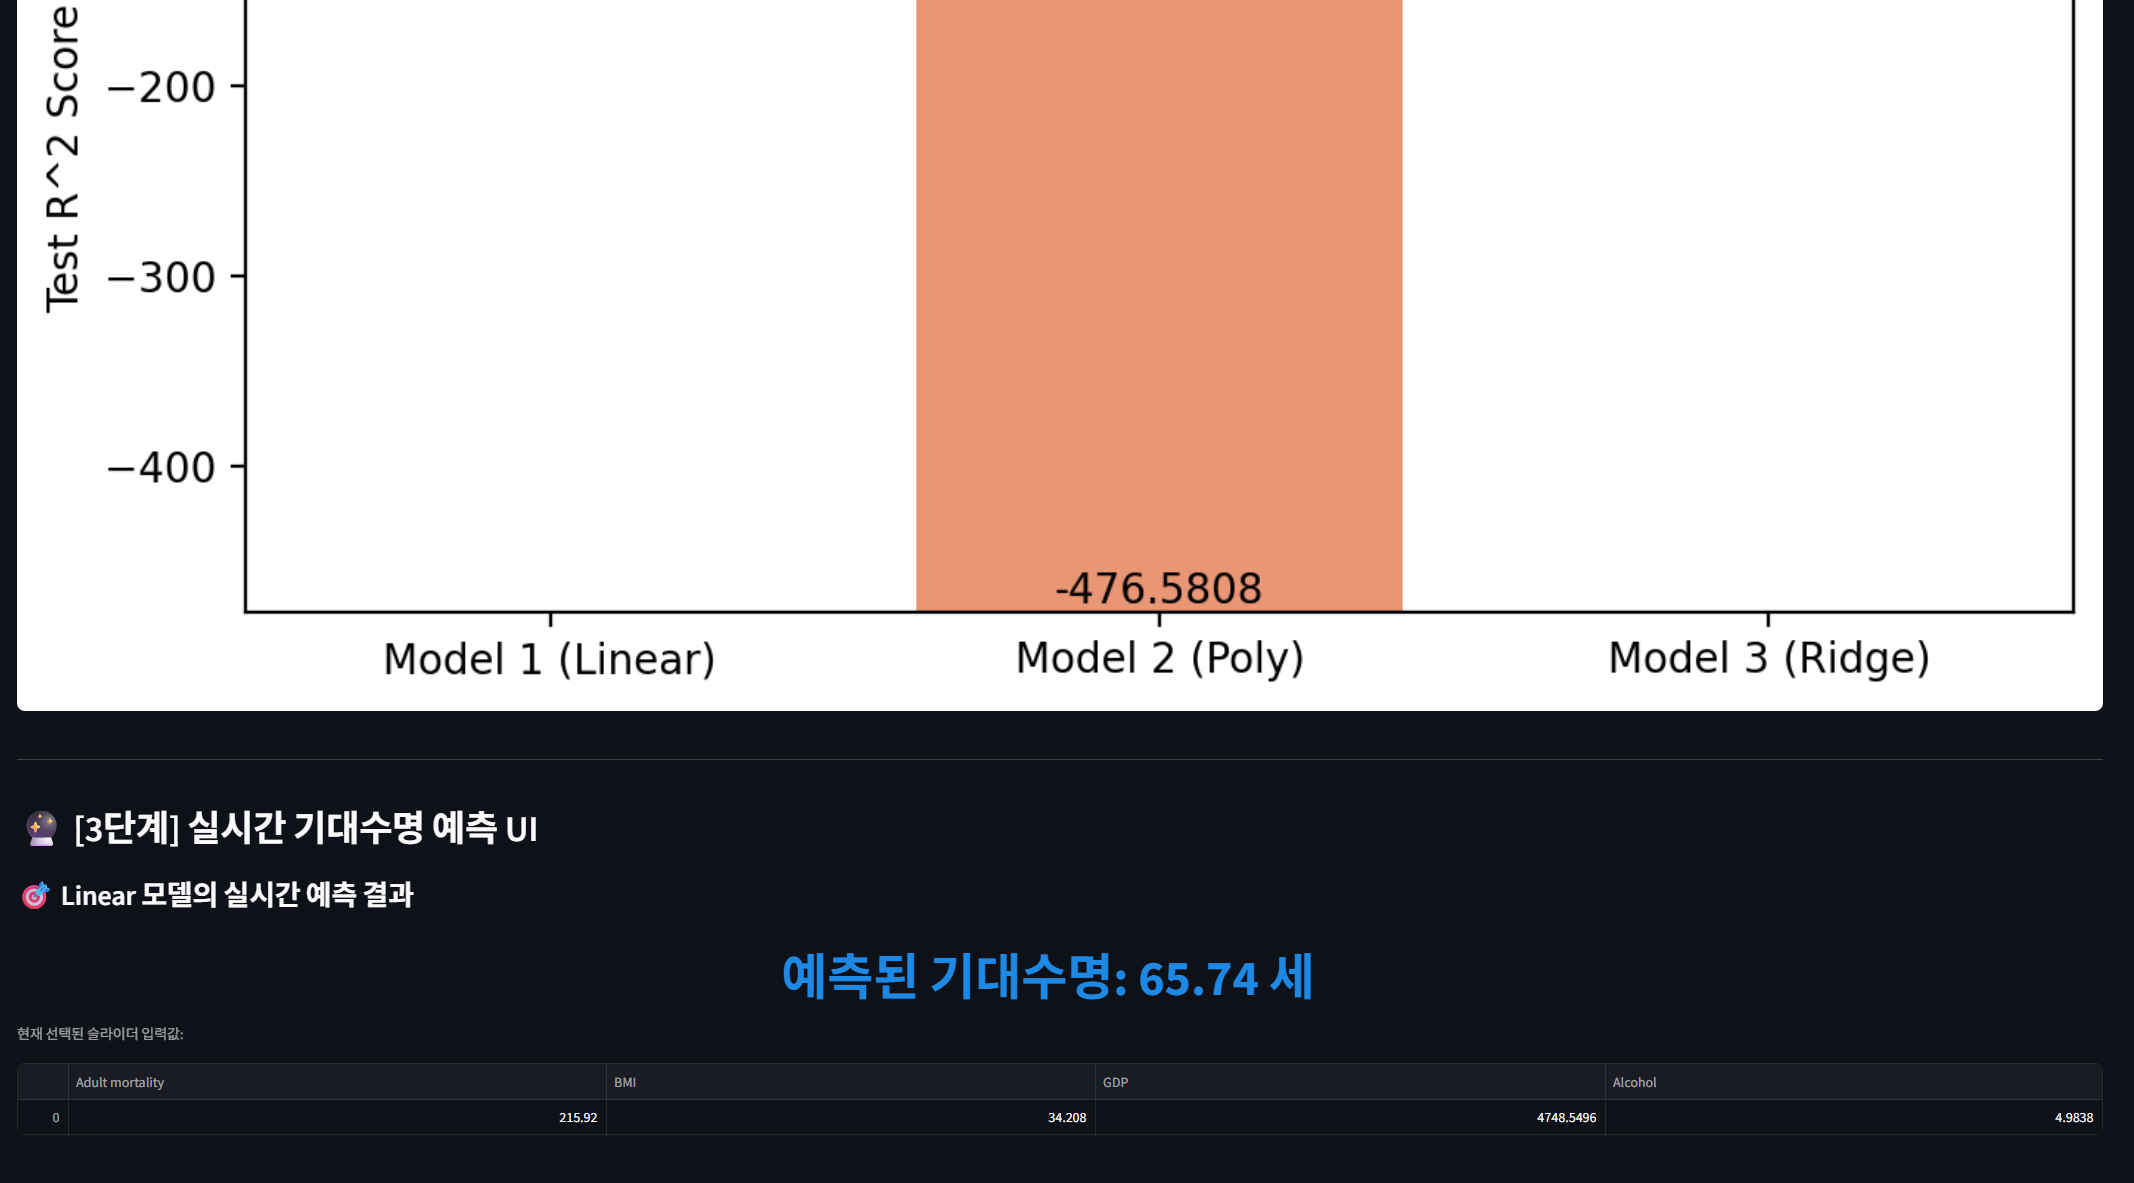